In [1]:
import os 

print(os.getcwd())
os.chdir('/root/autolabeling_time_series_data/')

import numpy as np

from core.generation import * 
from core.utils import * 

/root/autolabeling_time_series_data/tests


{'slope': 0.05263157894736836, 'noise_level': 0.22121212121212122}


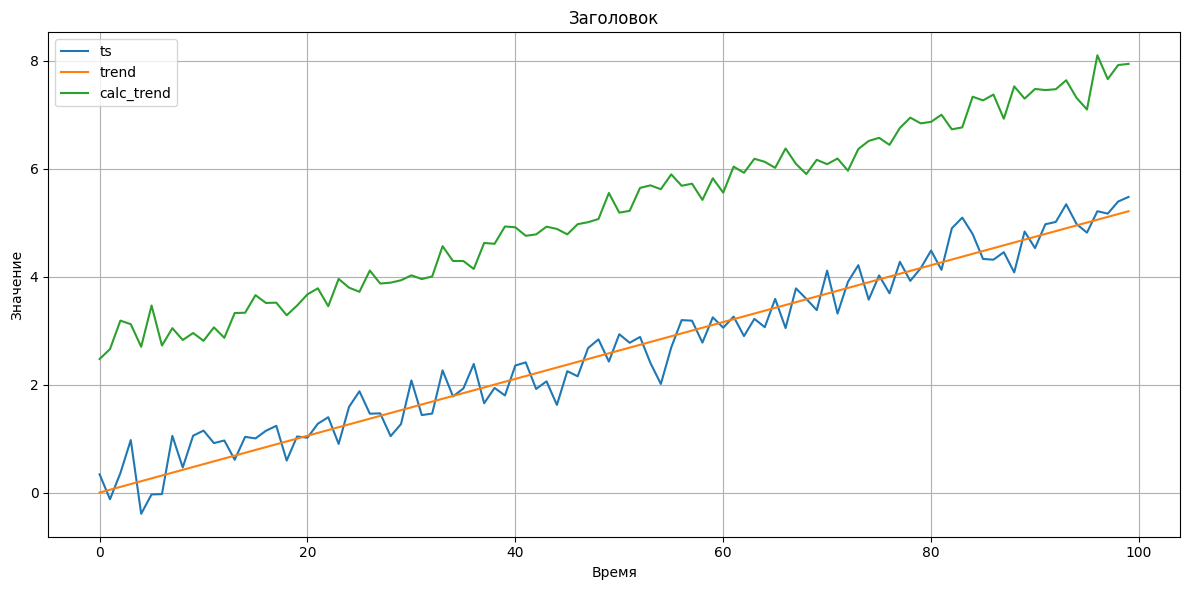

In [2]:
params = linear_trend_params(random_state=6)
# есть прблема, что шум бывает разный 
# params['noise_level'] = 0.3
print(params)
ts1, components = linear_trend(**params, length=100)
calc_trend = components['trend'] + np.random.normal(components['trend'].mean(), params['noise_level'], len(ts1))

plot_series([ts1,components['trend'], calc_trend], ['ts', 'trend', 'calc_trend'])

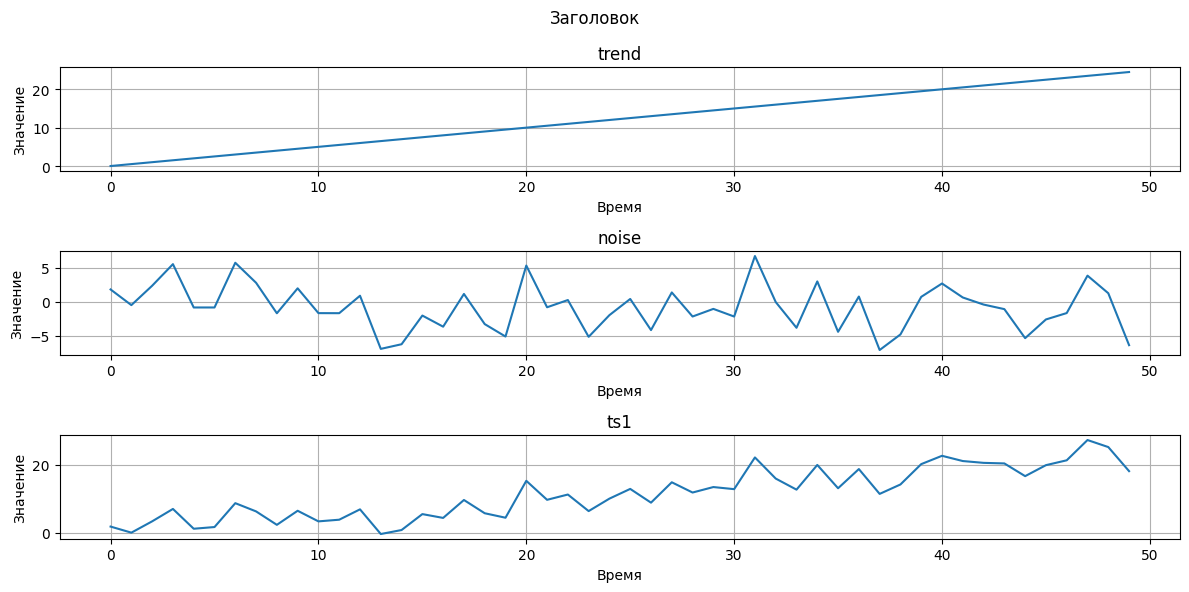

In [3]:
np.random.seed(42)
slope = 0.5
length = 50

trend = slope * np.arange(length)

noise_lvl = np.std(trend) * 0.5
noise = np.random.normal(0, noise_lvl, length)
ts1 = trend + noise

plot_series_grid([trend, noise, ts1], ['trend', 'noise', 'ts1'], layout='vertical')

2025-04-02 09:26:05 - [core.generation.ts_generators] - DEBUG - New block added. Blocks:[{'type': 'linear', 'params': {'slope': 1.5, 'noise_level': 0.01}}]
2025-04-02 09:26:05 - [core.generation.ts_generators] - DEBUG - New block added. Blocks:[{'type': 'linear', 'params': {'slope': 1.5, 'noise_level': 0.01}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.0, 'phase': 0.0, 'noise_level': 0.01}}]
2025-04-02 09:26:05 - [core.generation.ts_generators] - DEBUG - generate function block: {'type': 'linear', 'params': {'slope': 1.5, 'noise_level': 0.01}}
2025-04-02 09:26:05 - [core.generation.ts_generators] - DEBUG - Time series updates: (20,), [2.80313900e-02 1.46669261e+00 2.94145016e+00 4.55290646e+00
 6.08917550e+00 7.58055035e+00 8.92741254e+00 1.04732549e+01
 1.20286524e+01 1.35843790e+01 1.49585542e+01 1.64839416e+01
 1.79043084e+01 1.93965350e+01 2.10702788e+01 2.26173069e+01
 2.39937715e+01 2.55867998e+01 2.70312794e+01 2.84442009e+01]
2025-04-02 09:26:05 - [core.g

Generated time series: [2.80313900e-02 1.46669261e+00 2.94145016e+00 4.55290646e+00
 6.08917550e+00 7.58055035e+00 8.92741254e+00 1.04732549e+01
 1.20286524e+01 1.35843790e+01 1.49585542e+01 1.64839416e+01
 1.79043084e+01 1.93965350e+01 2.10702788e+01 2.26173069e+01
 2.39937715e+01 2.55867998e+01 2.70312794e+01 2.84442009e+01
 3.15005082e+01 3.40748682e+01 3.63731527e+01 3.75676944e+01
 3.84743561e+01 3.81996351e+01 3.70833119e+01 3.52524167e+01
 3.26424959e+01 2.99190904e+01 2.69790299e+01 2.42098664e+01
 2.16058263e+01 1.97267777e+01 1.86594422e+01 1.85368916e+01
 1.91587096e+01 2.05884263e+01 2.28472938e+01 2.55035135e+01]


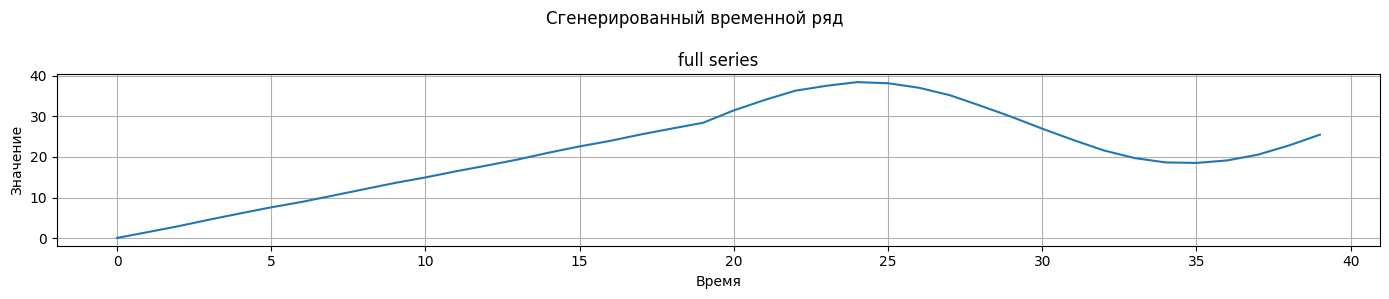

(40,)


In [4]:
generator = Generator(block_length=20)

# добавляем блоки
generator.add_block("linear", slope=1.5, noise_level=0.01)
generator.add_block("seasonal", amplitude=10.0, frequency=1.0, phase=0.0, noise_level=0.01)

# Генерация временного ряда
time_series = generator.generate()

# Вывод результата
print("Generated time series:", time_series)

# Визуализация результатов
plot_series_grid(
    [time_series],
    ['full series'],
    plot_title="Сгенерированный временной ряд",
    xlabel="Время",
    ylabel="Значение",
    figsize=(14, 3),
    layout='horizontal'
)


print(time_series.shape)

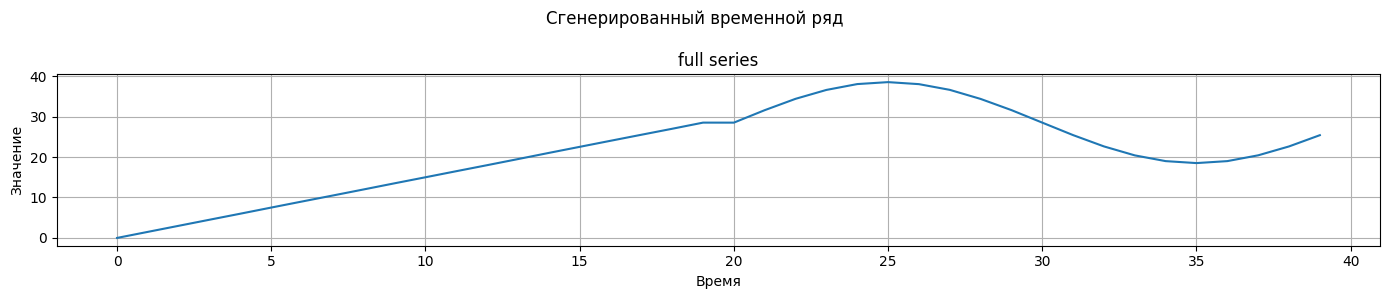

In [5]:
lt=[float(el) for el in """5.05215979e-03 1.50490424e+00 3.00495245e+00 4.50506212e+00 5.99794611e+00 7.51104426e+00 9.00842217e+00 1.04946339e+01
 1.19943499e+01 1.35068266e+01 1.49954603e+01 1.64961867e+01
 1.79840497e+01 1.94910256e+01 2.10144601e+01 2.25134061e+01
 2.40110110e+01 2.55008404e+01 2.69818708e+01 2.84987424e+01
 2.84967413e+01 3.15766736e+01 3.43806362e+01 3.65782636e+01
 3.80238058e+01 3.85072525e+01 3.80080507e+01 3.65982915e+01
 3.43551406e+01 3.15912448e+01 2.84958007e+01 2.54107452e+01
 2.26185454e+01 2.04038354e+01 1.89856525e+01 1.85009356e+01
 1.89881627e+01 2.04192694e+01 2.26165197e+01 2.53972780e+01""".split(' ')]

ts2=np.array(lt)

# Визуализация результатов
plot_series_grid(
    [ts2],
    ['full series'],
    plot_title="Сгенерированный временной ряд",
    xlabel="Время",
    ylabel="Значение",
    figsize=(14, 3),
    layout='horizontal'
)

2025-04-03 06:02:10 - [core.generation.ts_datasets] - DEBUG - Random state is set by 21
2025-04-03 06:02:10 - [core.generation.ts_datasets] - INFO - Dataset config file: {'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': 'None'}, {'type': 'seasonal', 'params': 'None'}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': 'None'}, {'type': 'linear', 'params': 'None'}]}], 'output': {'save_path': 'data/synth_dt1/synthetic_dataset1.json', 'save_dir_path': 'data/synth_dt1/pics'}}
2025-04-03 06:02:10 - [core.generation.ts_datasets] - DEBUG - Generation params from config file: {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q':

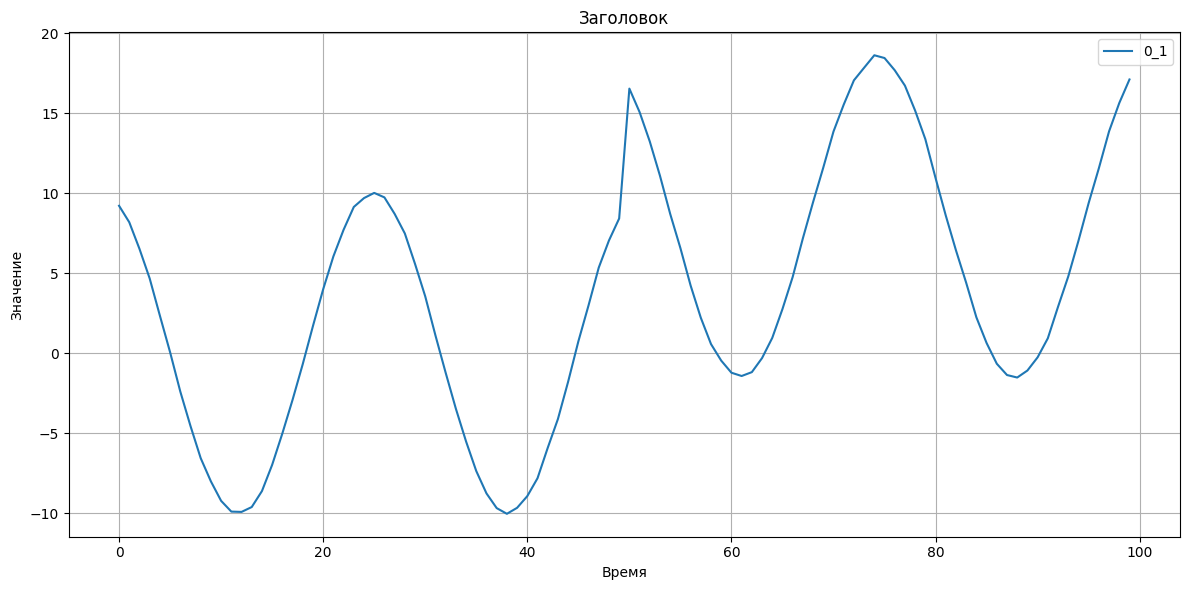

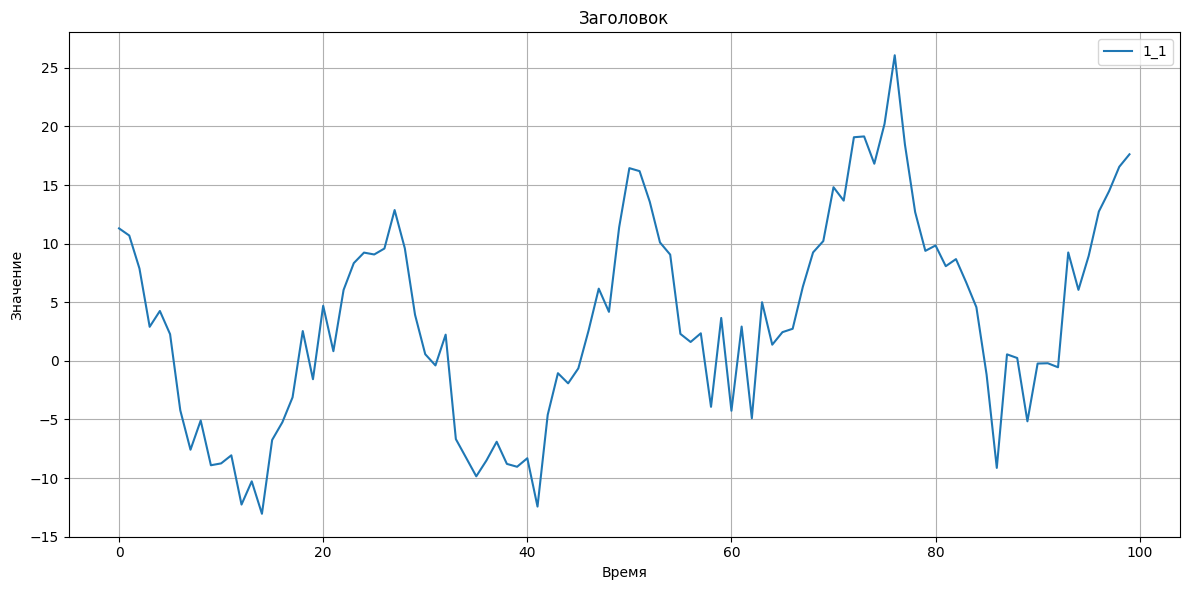

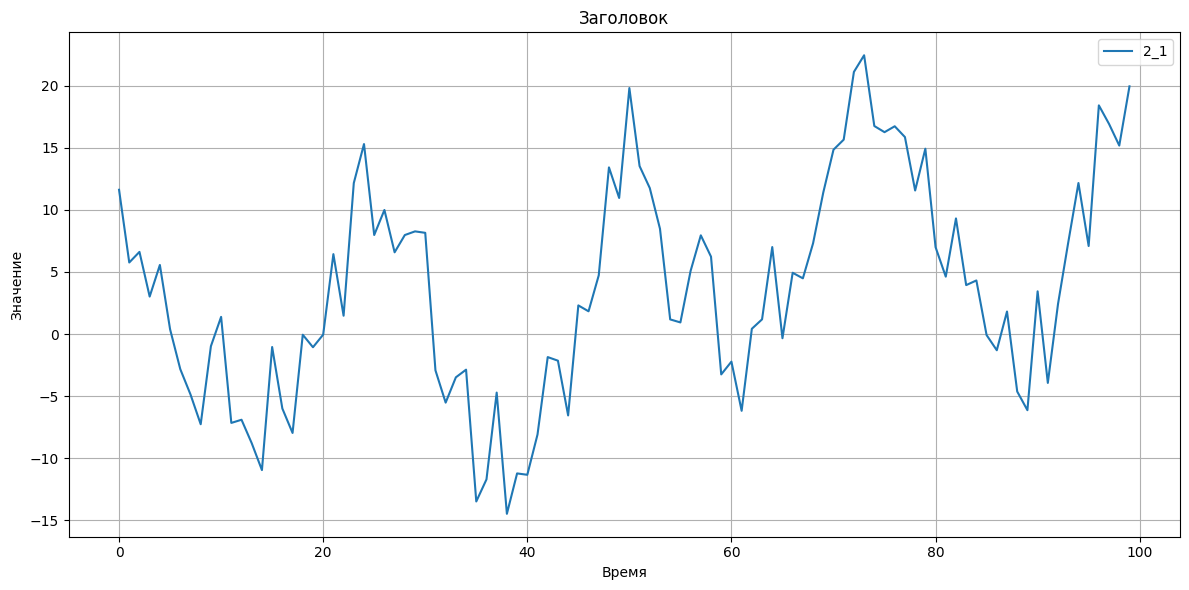

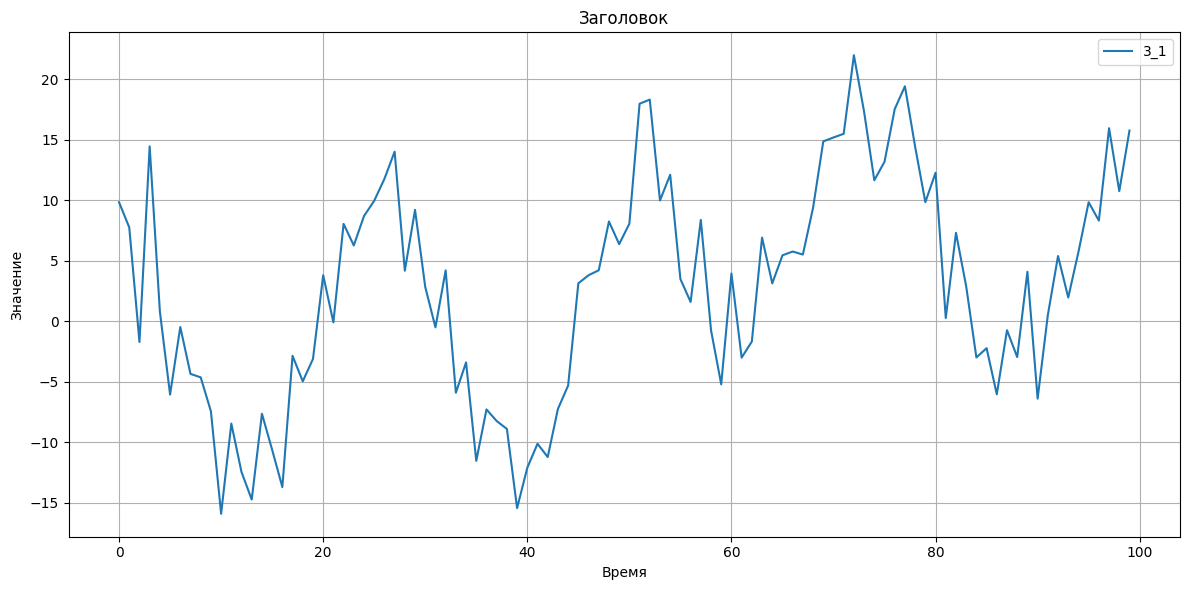

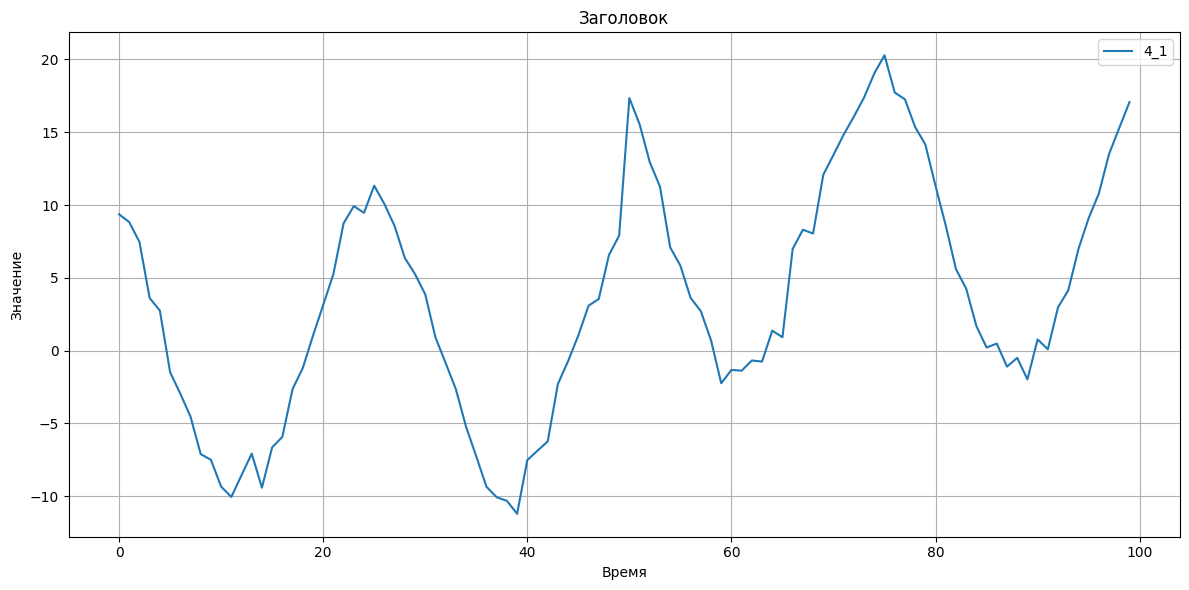

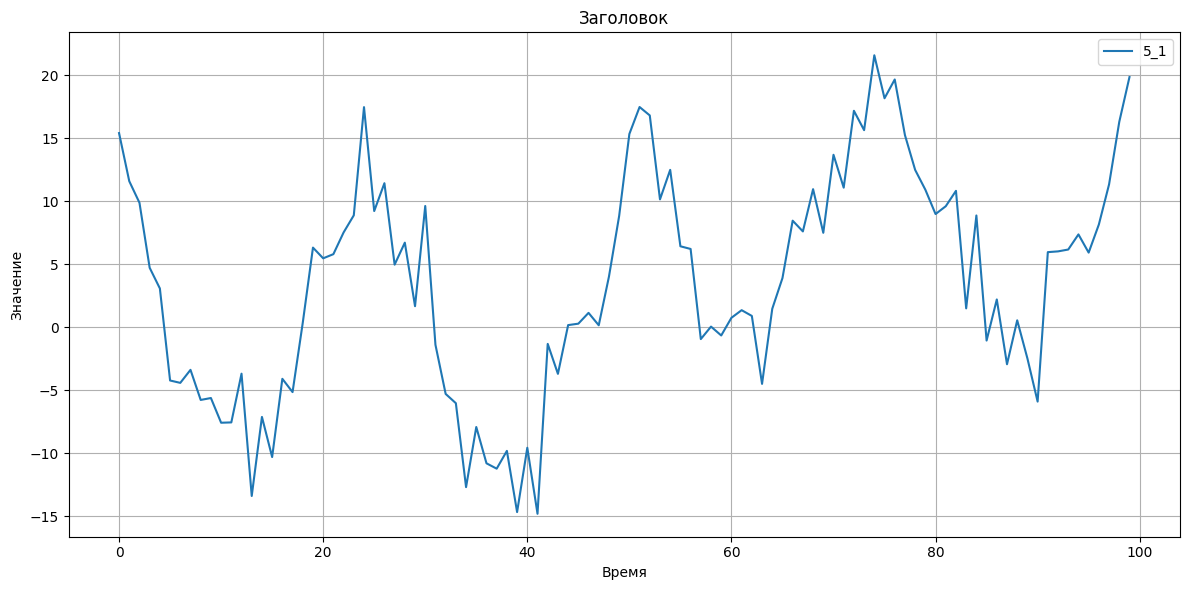

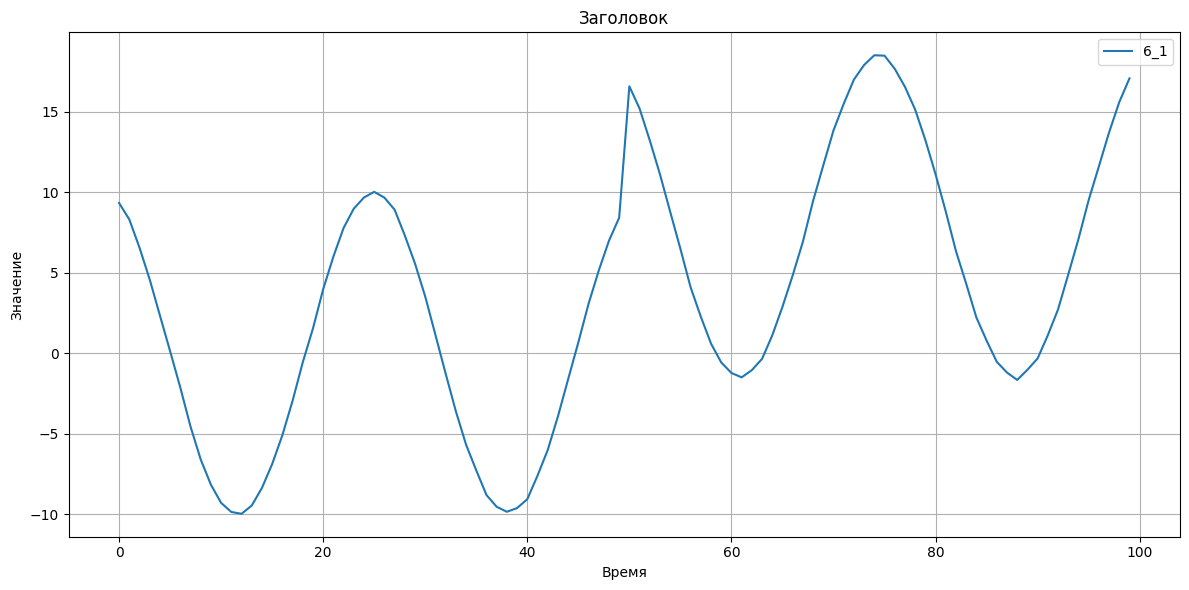

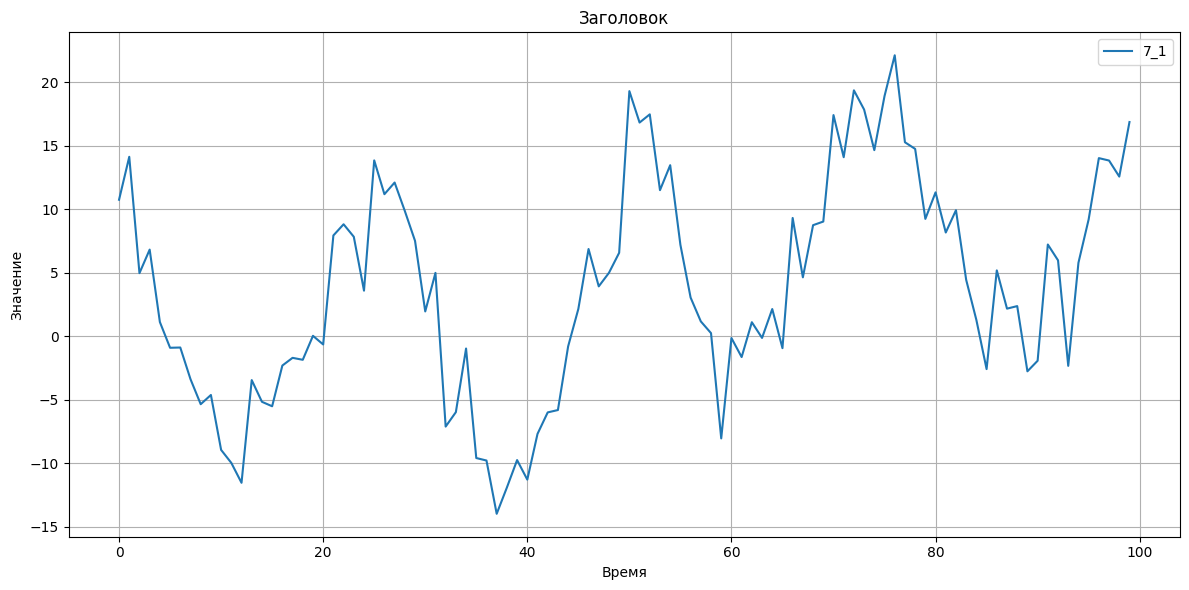

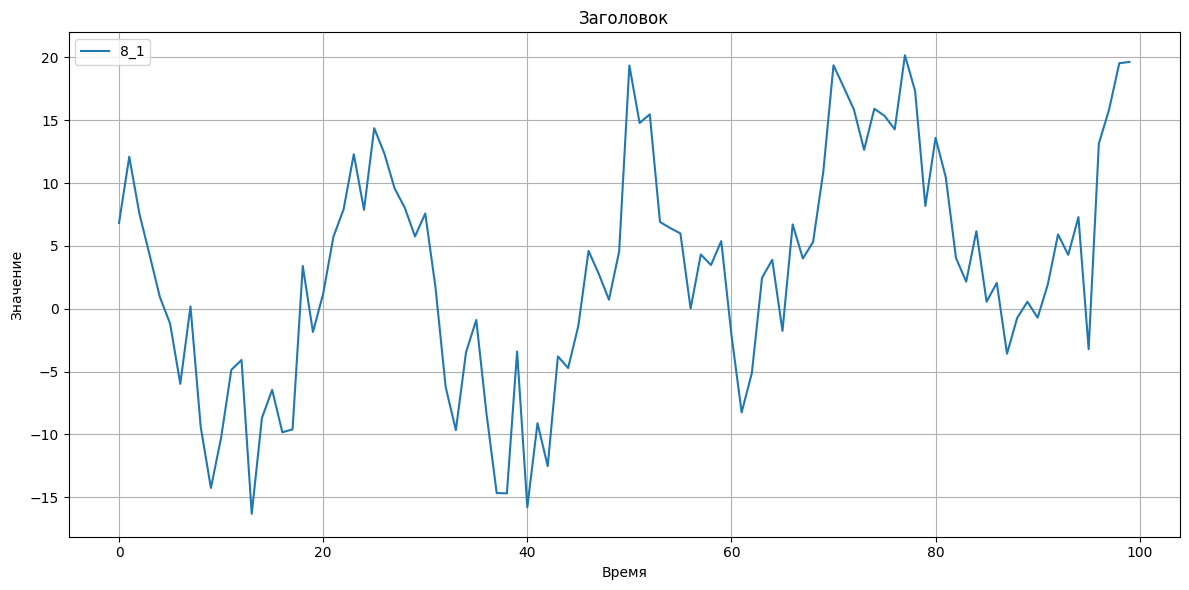

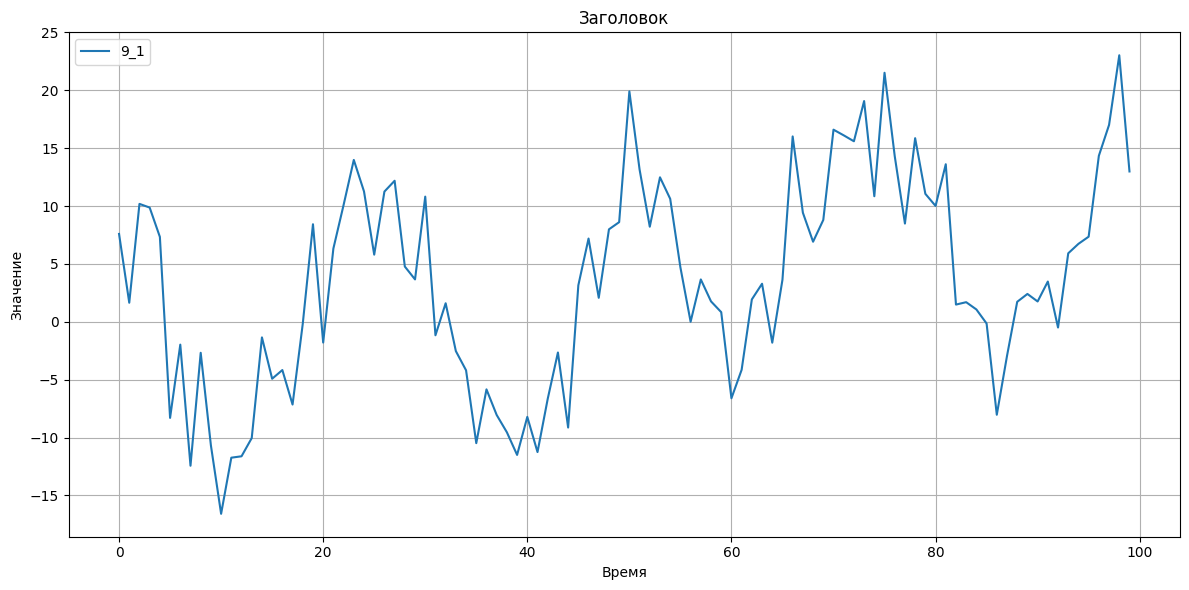

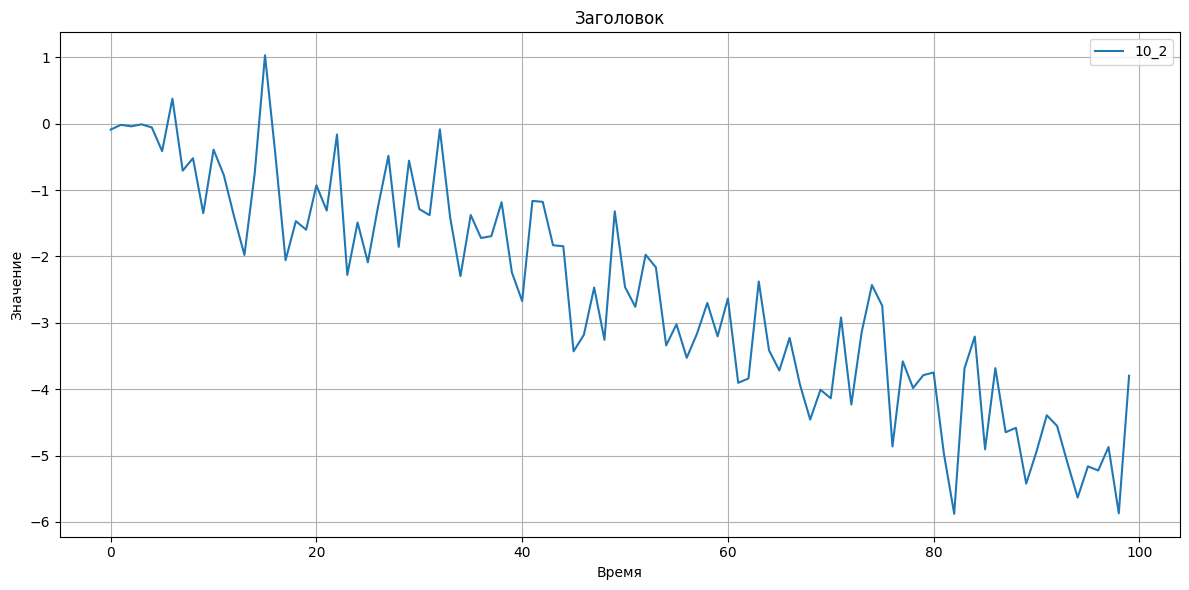

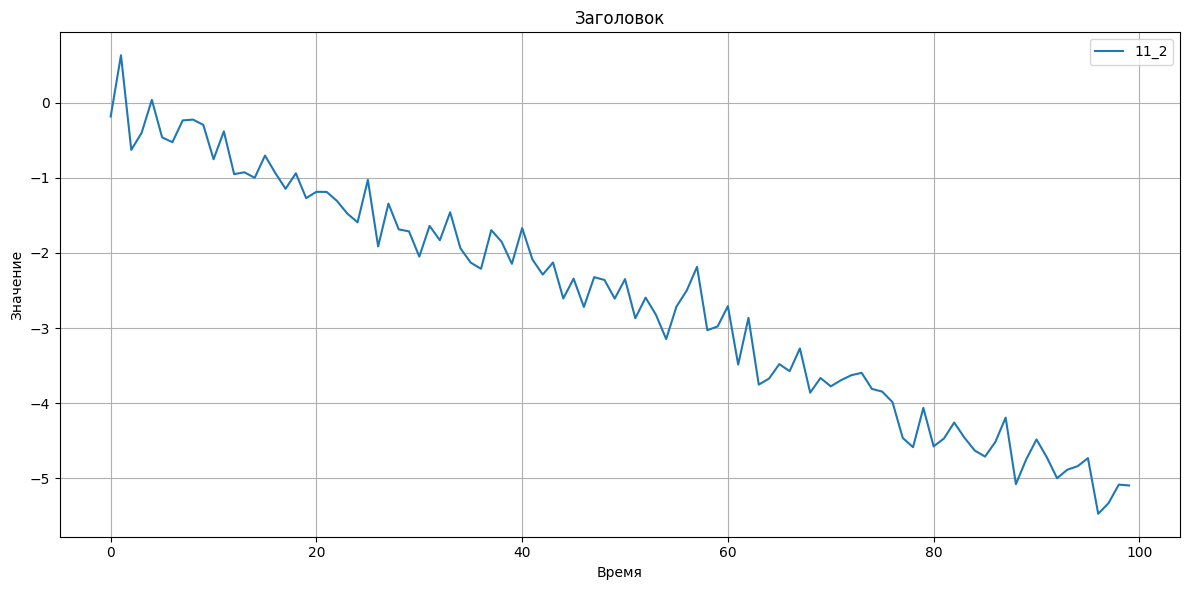

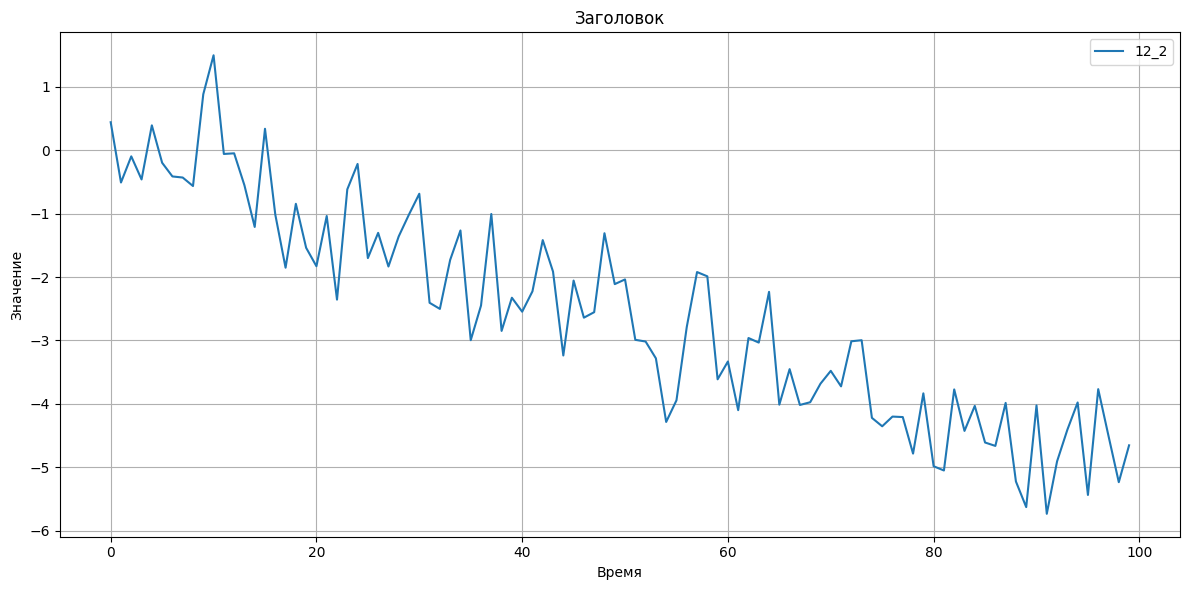

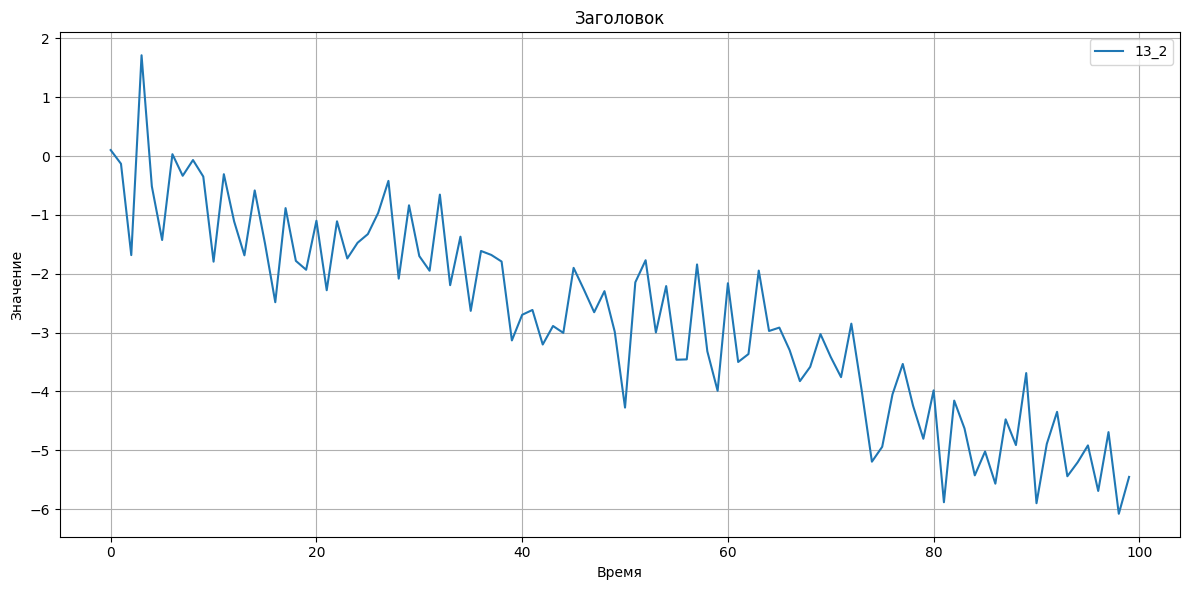

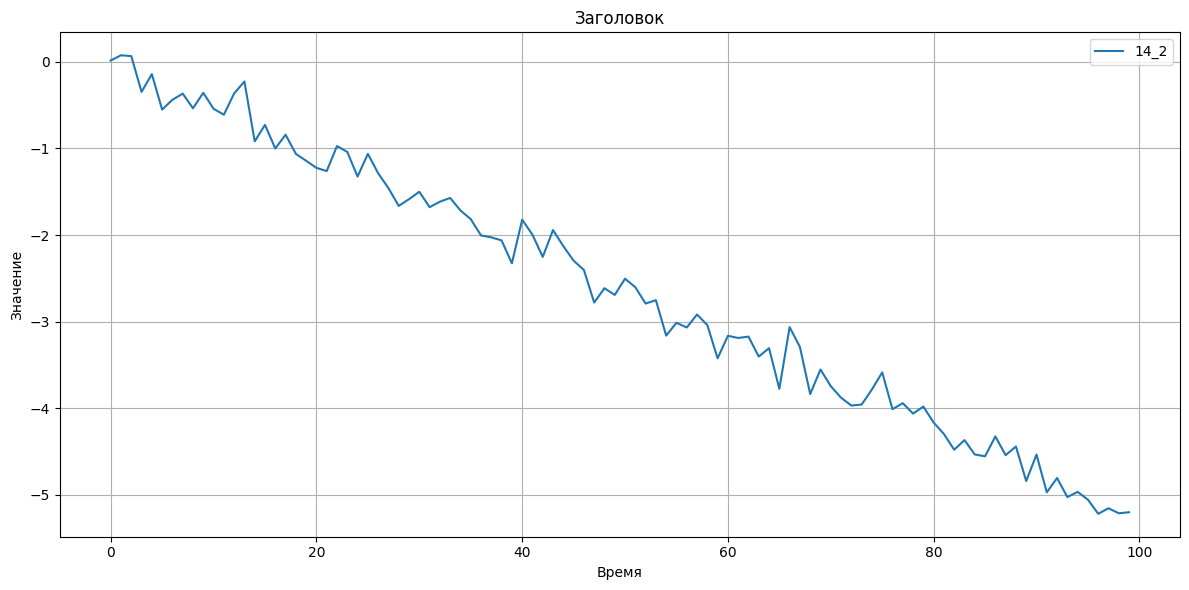

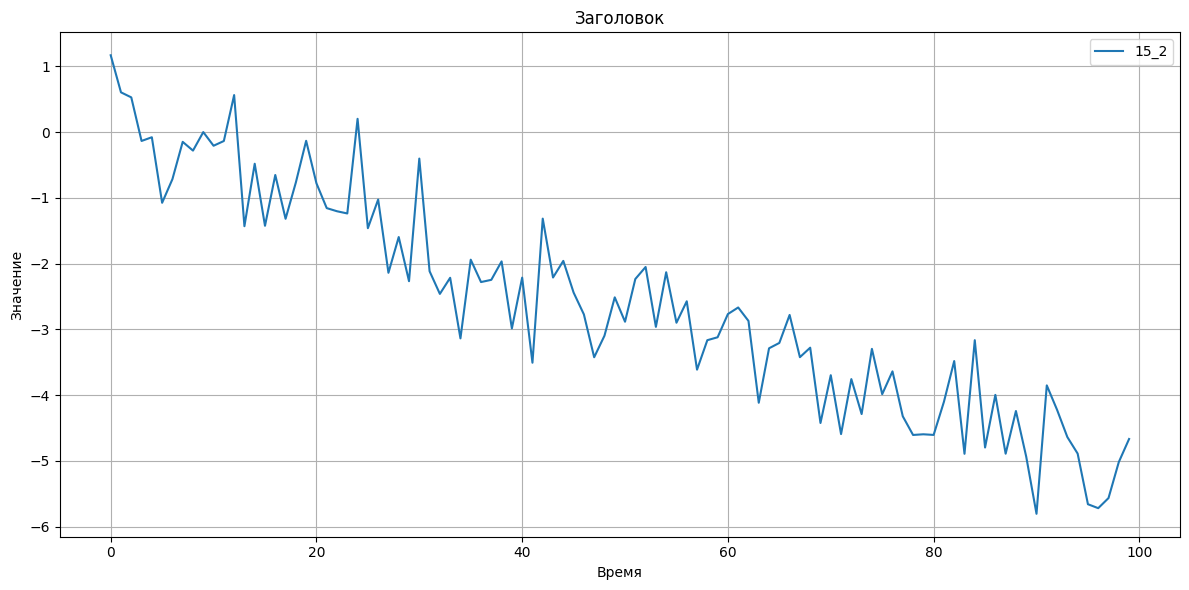

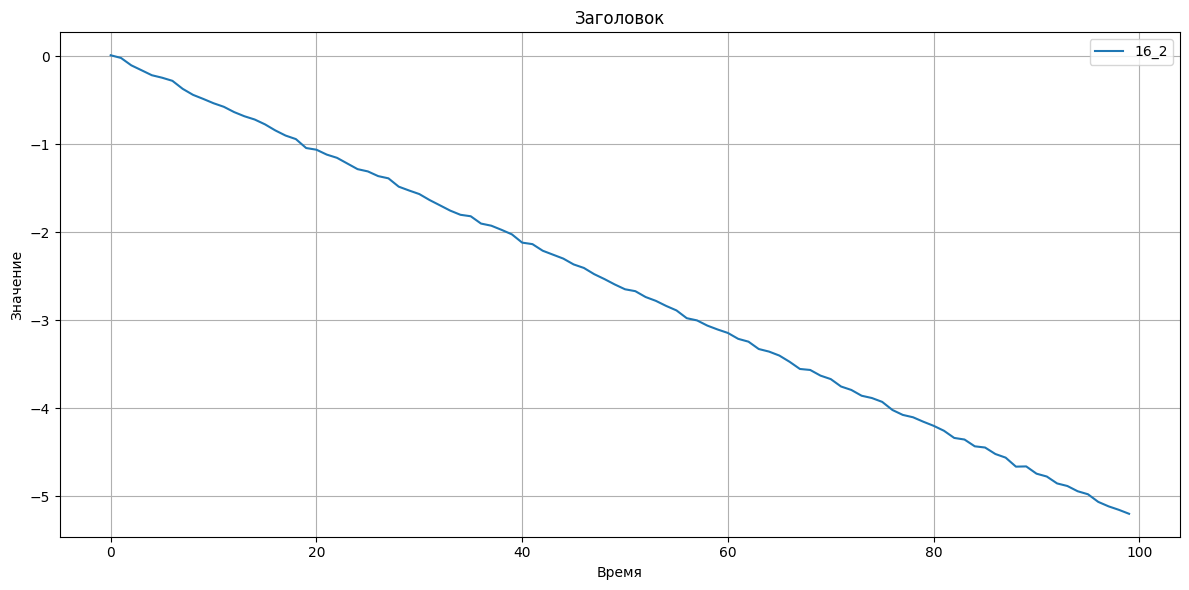

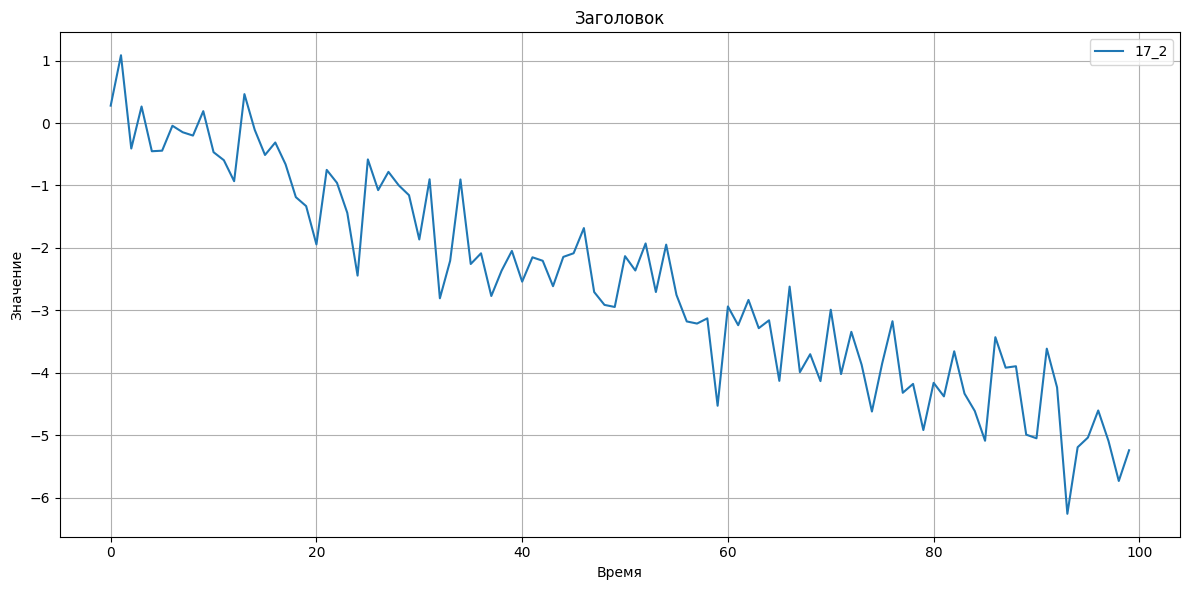

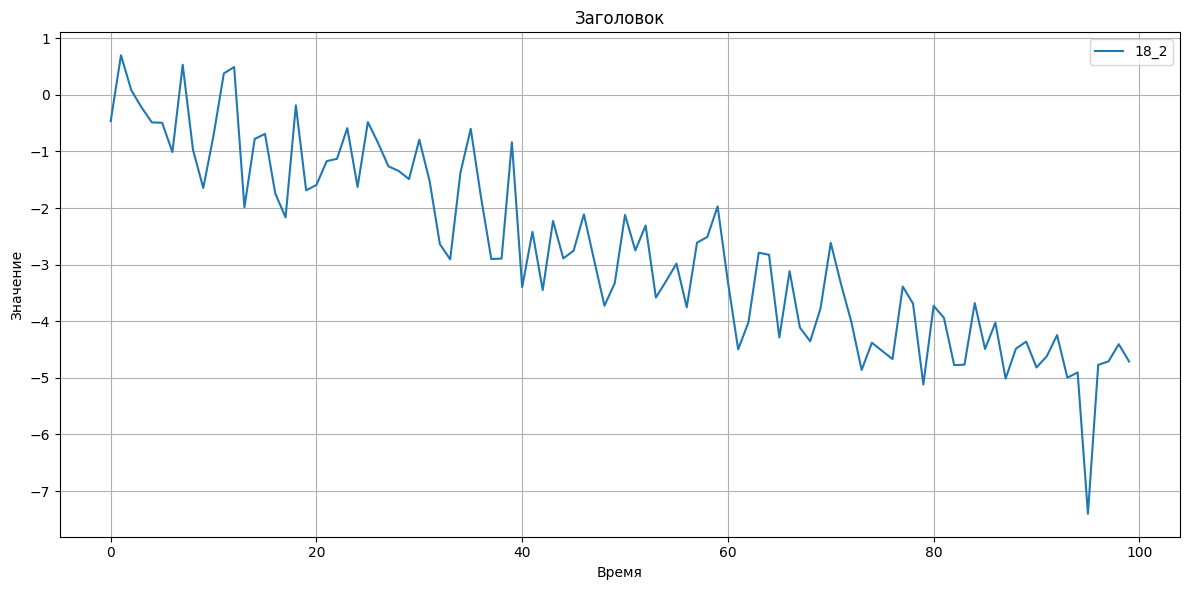

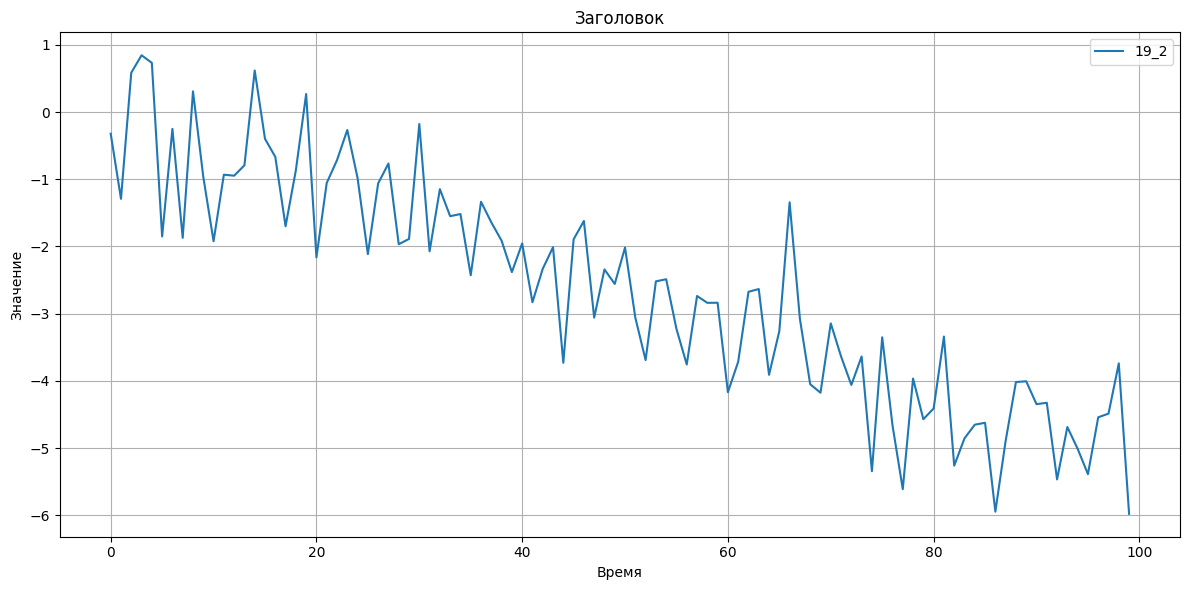

In [2]:
Synthetic_dataset_generator('.configs/base_synthetic_config.yaml')

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 0: [  9.21870992   8.1907034    6.52704182   4.67895438   2.3540607
   0.06937423  -2.3895963   -4.54523315  -6.55427668  -8.00559328
  -9.22085413  -9.89323328  -9.91289137  -9.60874094  -8.61190562
  -6.97322132  -5.01052461  -2.91018685  -0.67357505   1.70809886
   4.00293184   6.05502125   7.71925907   9.14461409   9.69877327
  10.02345041   9.74286606   8.71416688   7.48928576   5.58454942
   3.55623171   1.11673576  -1.21411539  -3.46149859  -5.50991635
  -7.35861185  -8.75647342  -9.67515581 -10.03068798  -9.65699548
  -8.92563114  -7.80880343  -5.91151133  -4.10748569  -1.77685273
   0.73862973   2.99461362   5.3532786    7.04822874   8.4233591
  16.54068513  15.0757645   13.23552741  11.09060264   8.71073419
   6.57407485   4.23693216   2.22048384   0.5741529   -0.45916209
  -1.21452464  -1.41971326  -1.17825755  -0.30020099   0.96197107
   2.76437396   4.76687354   7.18447559   9.44675472  11.60685251
  13.8

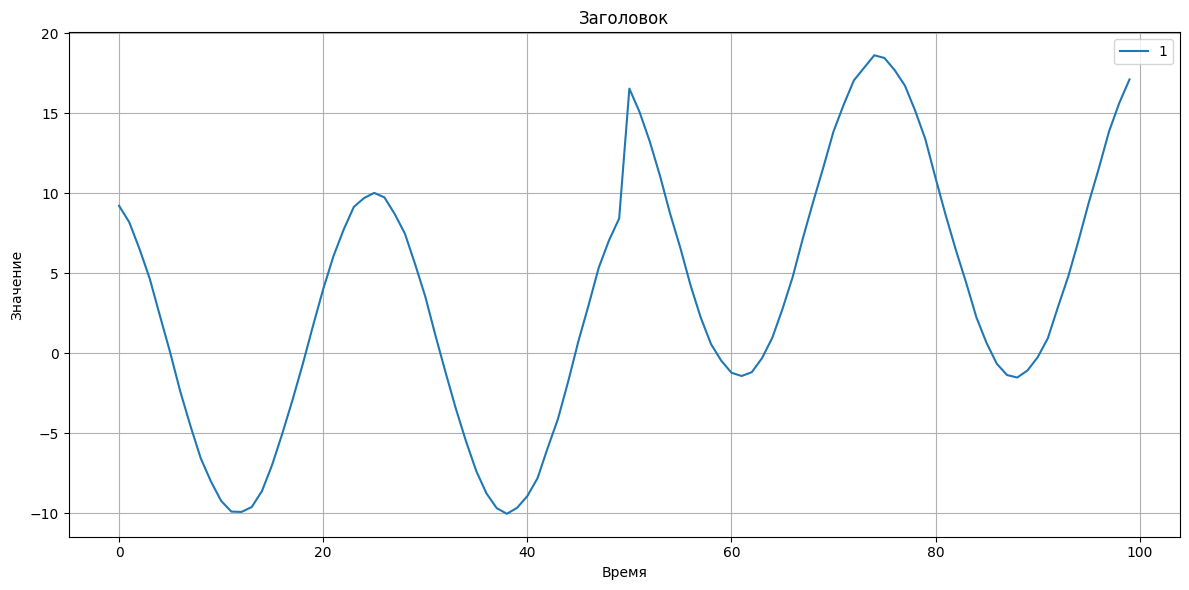

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 1: [ 11.30195837  10.69388738   7.87525329   2.9048781    4.25662312
   2.27626075  -4.22088099  -7.58126262  -5.09038114  -8.9069924
  -8.74815673  -8.05913232 -12.26013312 -10.27981973 -13.04838359
  -6.74737181  -5.24216842  -3.11304855   2.54400218  -1.56864812
   4.70247225   0.8231324    6.05261777   8.33898757   9.23564859
   9.07650188   9.58404661  12.86574144   9.60039382   3.93348877
   0.56610433  -0.38930992   2.23635777  -6.67562192  -8.2602677
  -9.85099711  -8.49590544  -6.90107693  -8.79149277  -9.03582895
  -8.30815576 -12.43203173  -4.60450048  -1.05297409  -1.91880513
  -0.64015503   2.57744458   6.16016857   4.18124603  11.40131755
  16.44211719  16.18612578  13.57036684  10.1029948    9.0628829
   2.29956139   1.61106703   2.35060653  -3.92164827   3.66089285
  -4.25794315   2.92579508  -4.89837676   4.99964569   1.37962364
   2.4495519    2.73747695   6.33135307   9.25358147  10.21970091
  14.81

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


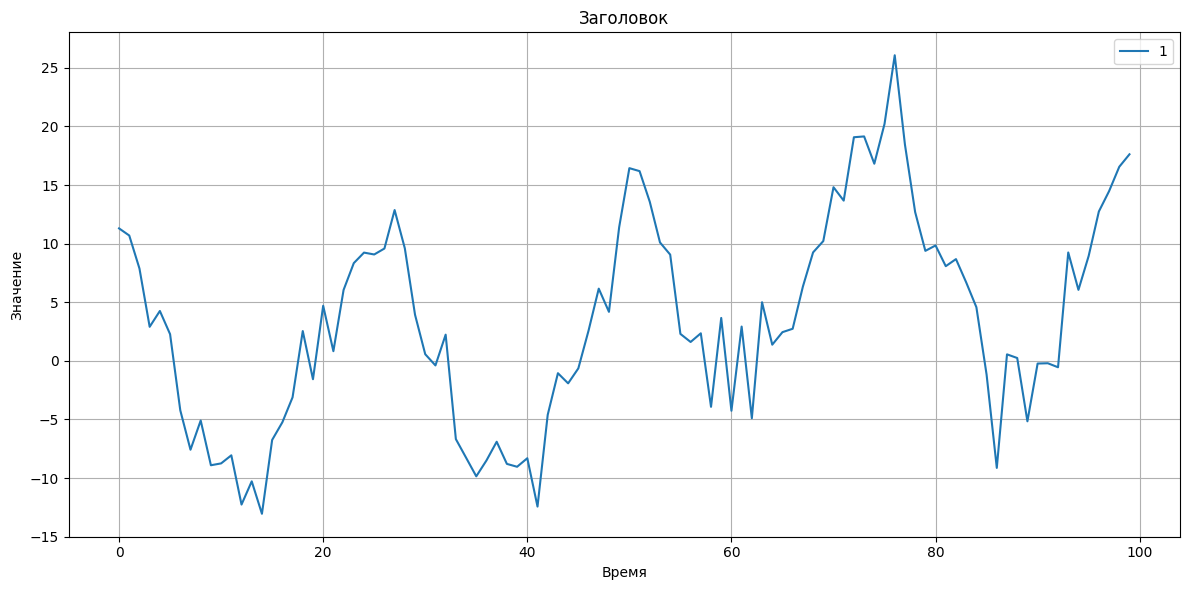

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 2: [ 11.61104921   5.75915182   6.61257514   3.01659054   5.56044441
   0.38521838  -2.82425854  -4.86118918  -7.25717993  -0.97648604
   1.38362026  -7.14989594  -6.89546274  -8.7839121  -10.94711539
  -1.04284855  -5.99261765  -7.95867497  -0.05420399  -1.06072807
  -0.04643495   6.43067775   1.47538342  12.1517015   15.29062063
   7.97145326   9.98525986   6.57856739   7.96817377   8.26338202
   8.14652867  -2.91814091  -5.51742095  -3.48244444  -2.86519401
 -13.47186652 -11.69518667  -4.70967399 -14.46359183 -11.21385692
 -11.32477009  -8.08475911  -1.85282494  -2.142414    -6.54716068
   2.30536292   1.8315701    4.72387034  13.41334459  10.95129743
  19.79604446  13.51830679  11.75014356   8.4717449    1.17875065
   0.93584789   5.08393898   7.9446069    6.22730098  -3.24623007
  -2.21904257  -6.17476837   0.4247011    1.1829883    7.00081174
  -0.33625971   4.93174859   4.48404906   7.30615987  11.3936582
  14.

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


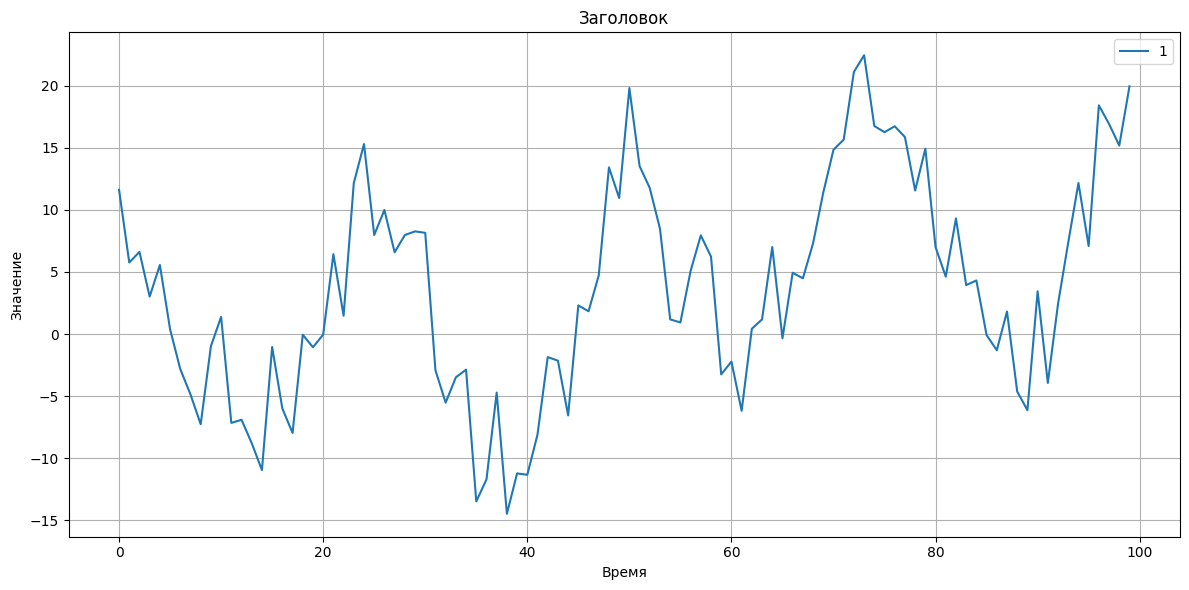

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 3: [  9.82792718   7.7480346   -1.72040532  14.44051672   0.7960402
  -6.06601664  -0.48160855  -4.35521042  -4.64176454  -7.44432962
 -15.91443107  -8.45931269 -12.47146047 -14.73873952  -7.65175565
 -10.62537222 -13.70921109  -2.86569915  -4.96858683  -3.12243058
   3.79732341  -0.09319858   8.03674068   6.2571982    8.69009956
   9.94694314  11.75805635  14.00417901   4.16849768   9.19524032
   2.82708997  -0.50928236   4.19619965  -5.9127228   -3.40797941
 -11.54302927  -7.29173721  -8.24971283  -8.90118494 -15.44559351
 -12.10972554 -10.12601824 -11.22536655  -7.24923148  -5.31852011
   3.12795541   3.7955233    4.20720859   8.23699871   6.36612874
   8.05125934  17.96517117  18.30717402   9.9769247   12.09789953
   3.48193334   1.58857936   8.36733539  -0.74882012  -5.21689477
   3.93988766  -3.01149445  -1.68260249   6.90457472   3.12539976
   5.44116125   5.75575909   5.50474322   9.37700004  14.85390257
  15.

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


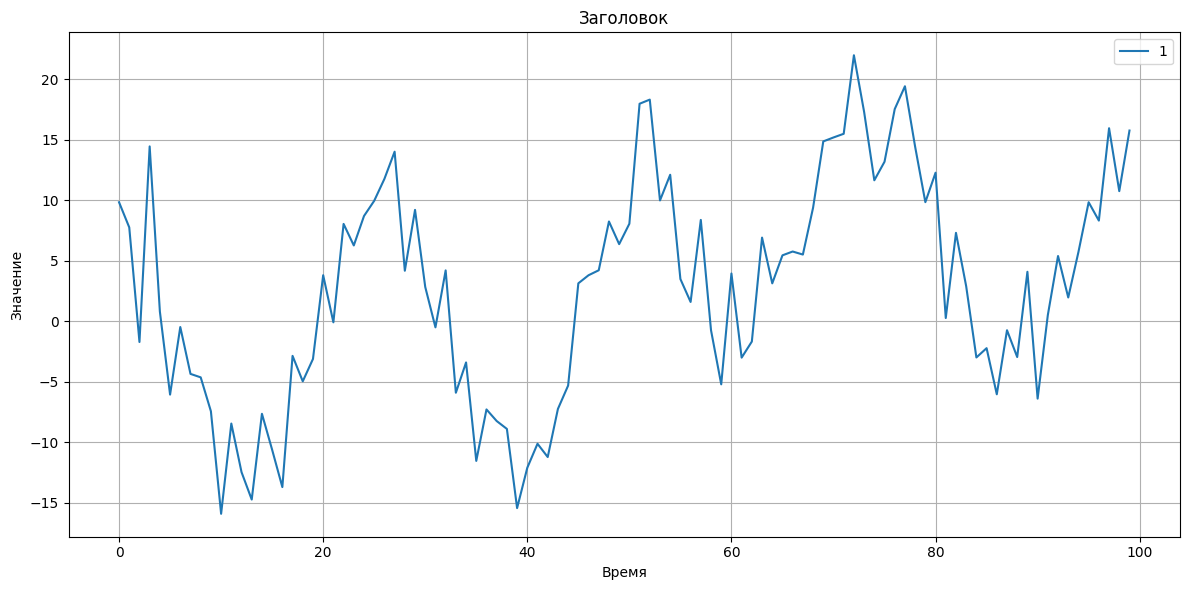

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 4: [  9.36665943   8.82859778   7.46230786   3.61043237   2.74883621
  -1.47475395  -2.9572216   -4.53074544  -7.10792513  -7.50041365
  -9.33829886 -10.05253723  -8.55886392  -7.07559664  -9.41418018
  -6.64812212  -5.92293631  -2.6435707   -1.19671168   1.02100022
   3.13402956   5.25682255   8.74454655   9.92786878   9.46726732
  11.32673582  10.07325514   8.55297041   6.3663593    5.25354738
   3.86850658   0.90876125  -0.85254515  -2.64831421  -5.23118244
  -7.27001234  -9.35281183 -10.07309212 -10.32017738 -11.20939301
  -7.51972441  -6.87487697  -6.23707344  -2.28703338  -0.71518692
   1.04507828   3.08788318   3.54721752   6.56141165   7.90984686
  17.35001624  15.55988492  12.94354308  11.26475648   7.09420606
   5.83562559   3.62368284   2.71538909   0.71085358  -2.24186295
  -1.32597451  -1.37928197  -0.67743366  -0.74987188   1.37110404
   0.92098284   6.98261655   8.3037929    8.04425514  12.08054306
  13

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


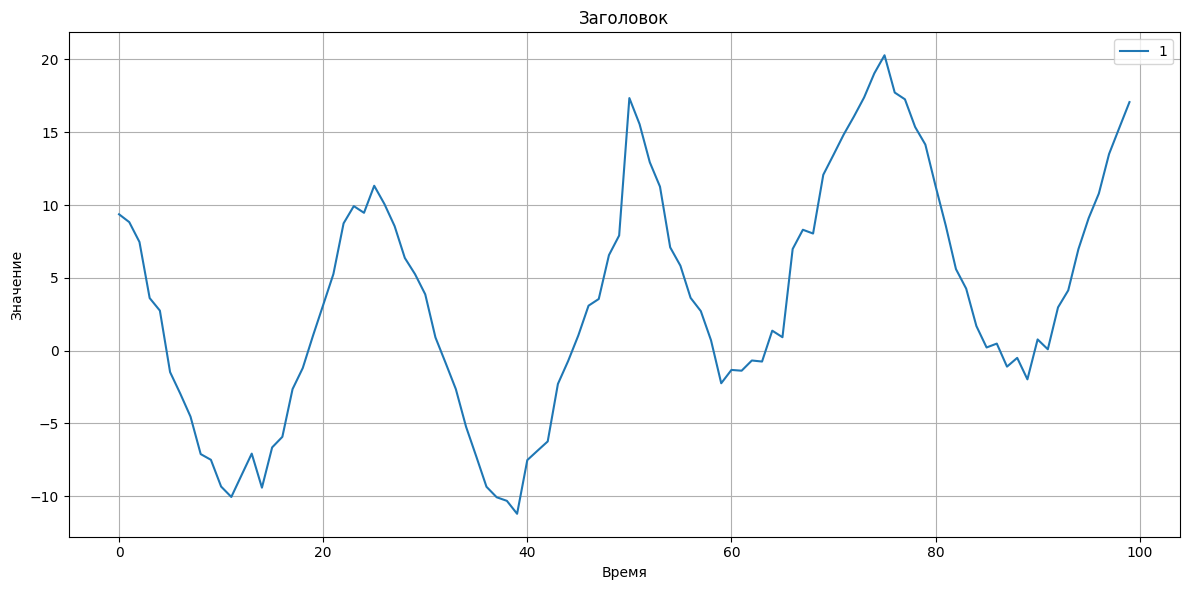

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 5: [ 15.42029117  11.60124743   9.88599473   4.72198855   3.07898511
  -4.23132302  -4.42054735  -3.38566977  -5.77650868  -5.62391644
  -7.58641145  -7.56085737  -3.6907262  -13.40439723  -7.12443801
 -10.31386191  -4.0978466   -5.15334418   0.35607737   6.32350886
   5.47319346   5.80318706   7.52650535   8.88852213  17.48097185
   9.22695036  11.43884339   4.96963903   6.71690597   1.66938504
   9.629344    -1.39552397  -5.2982969   -6.03477306 -12.70073695
  -7.9254328  -10.80857134 -11.23499854  -9.8226277  -14.68258259
  -9.57508432 -14.81939282  -1.32358915  -3.70396617   0.16850521
   0.28141201   1.14015963   0.15396981   4.02001722   8.8405414
  15.34968045  17.49011829  16.8223295   10.15491364  12.49871207
   6.42865437   6.21644953  -0.94277951   0.04842422  -0.65541982
   0.74903812   1.35381807   0.89670363  -4.49979506   1.46221368
   3.90386528   8.46262546   7.60952203  10.96580677   7.49794789
  13.

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


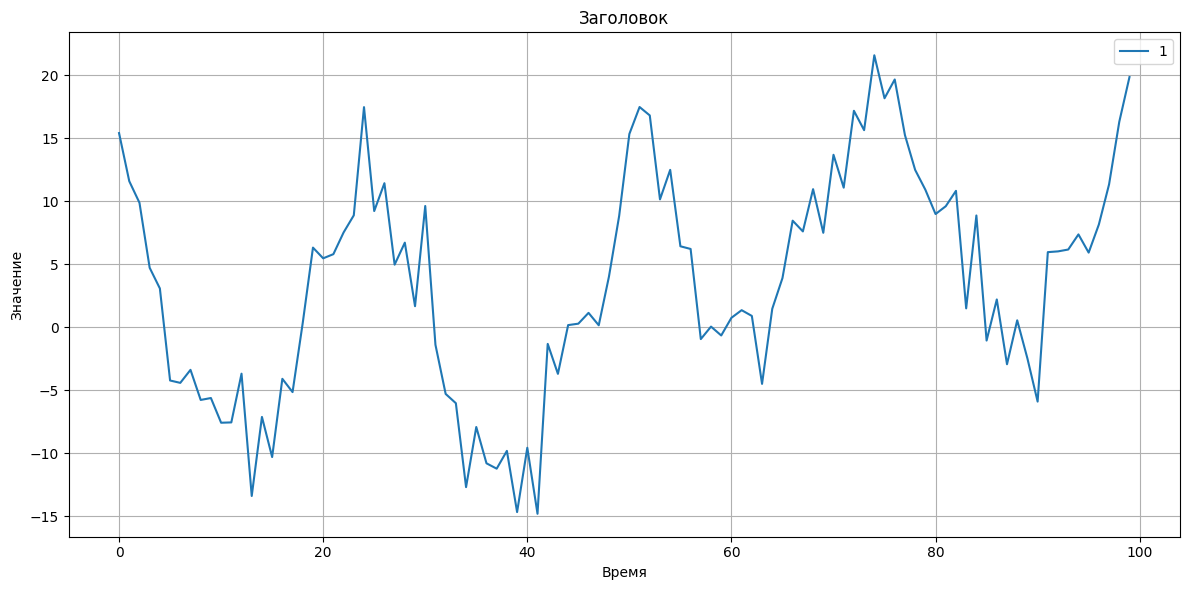

2025-04-03 05:46:37 - [core.generation.ts_datasets] - DEBUG - series 6: [ 9.34174428  8.32484172  6.57013122  4.59452799  2.3574099   0.13492769
 -2.12655766 -4.55126798 -6.59990414 -8.17101575 -9.30070073 -9.8656432
 -9.97899431 -9.46791168 -8.37053108 -6.89245476 -5.09610263 -2.96071809
 -0.56378456  1.5429063   3.98338253  6.00793109  7.78865848  8.98922014
  9.68440166 10.03198731  9.67538023  8.9235229   7.31888865  5.56995038
  3.52294157  1.13904243 -1.26600245 -3.60587425 -5.68247128 -7.2811617
 -8.81291365 -9.54355924 -9.85339933 -9.62227741 -9.06885714 -7.60687053
 -6.01564718 -3.92774532 -1.61653632  0.67844655  3.0717406   5.13824214
  6.99192897  8.42498115 16.59306387 15.2093549  13.23179971 11.11941403
  8.79457098  6.49179977  4.10188035  2.27238334  0.60096599 -0.56944681
 -1.22574001 -1.49767497 -1.04832097 -0.34877899  1.10984239  2.88796639
  4.83765022  6.9307135   9.46898259 11.68113994 13.85167737 15.50384772
 17.0113009  17.91953487 18.52341631 18.49743327 17.68

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


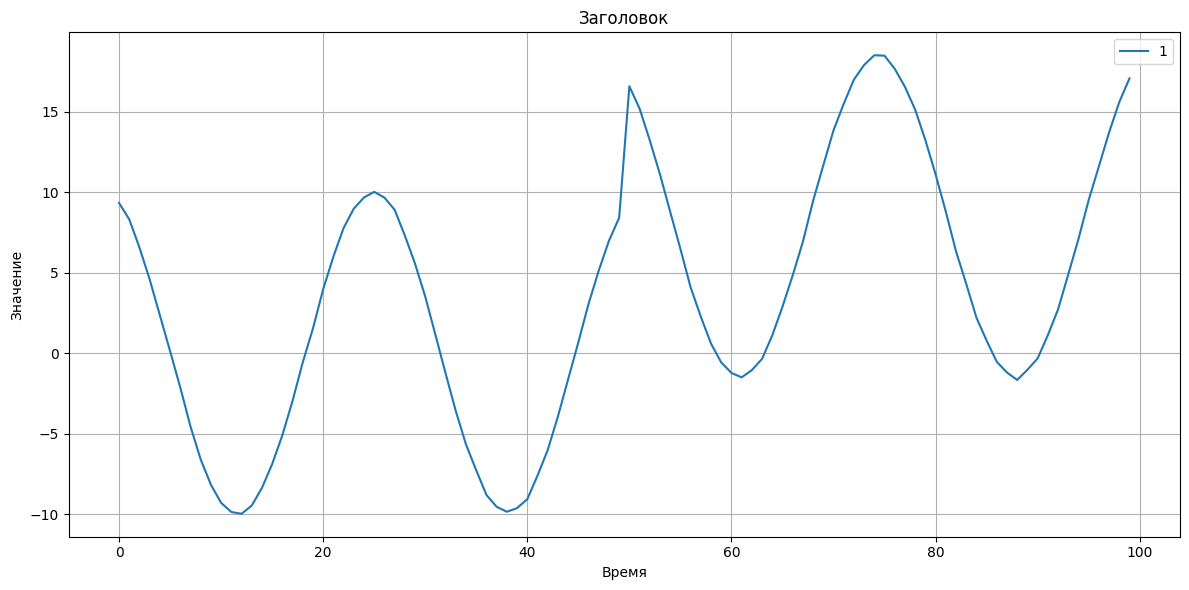

2025-04-03 05:46:38 - [core.generation.ts_datasets] - DEBUG - series 7: [ 10.74655549  14.12682409   4.96767367   6.82102453   1.11836969
  -0.90869267  -0.88799569  -3.37979707  -5.35097079  -4.62489468
  -8.94836531  -9.97358556 -11.53955037  -3.45366856  -5.16221587
  -5.51408253  -2.30837259  -1.70093621  -1.85491676   0.032155
  -0.64831823   7.93529186   8.8151596    7.83214511   3.58883942
  13.84593953  11.18386638  12.10135076   9.86207991   7.50897071
   1.95163289   4.98782071  -7.11371158  -5.97807948  -0.96793025
  -9.58922536  -9.78580932 -13.9803138  -11.9115492   -9.75081779
 -11.28900509  -7.68917132  -5.99617069  -5.81094991  -0.80072446
   2.14673515   6.86819254   3.9261684    4.99230225   6.57142308
  19.2999345   16.82492853  17.47000912  11.50191474  13.46759412
   7.20047181   3.04436614   1.16893686   0.24384689  -8.04466465
  -0.14039003  -1.63970692   1.10346781  -0.13289165   2.14112561
  -0.9379626    9.31184531   4.63749778   8.7443792    9.02957779
  17.4

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


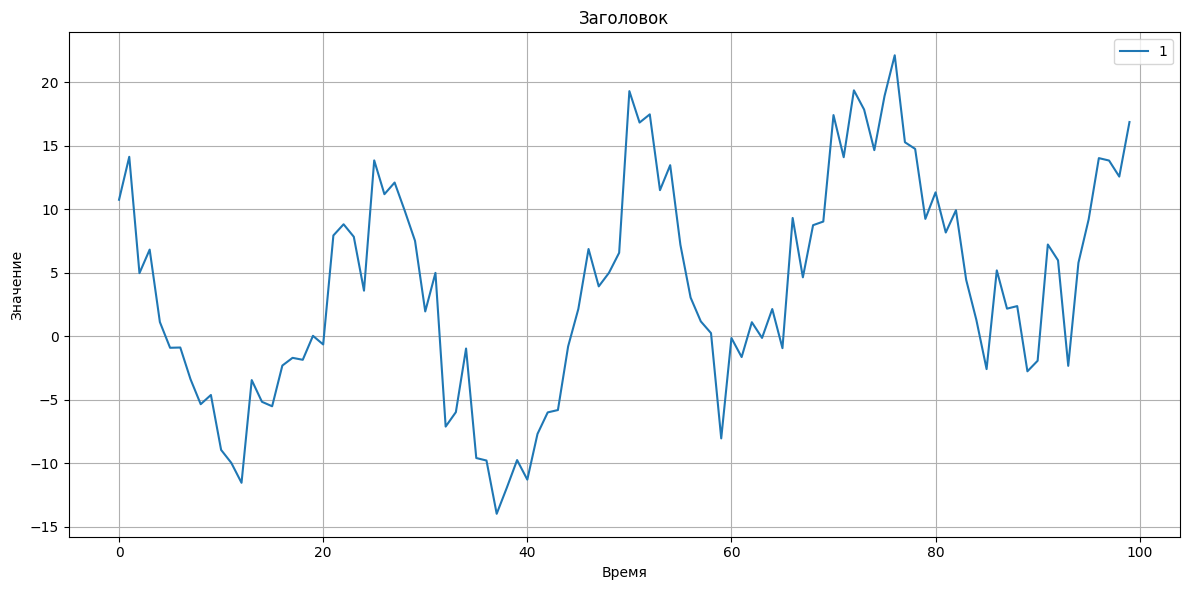

2025-04-03 05:46:38 - [core.generation.ts_datasets] - DEBUG - series 8: [ 6.83375234e+00  1.20938015e+01  7.54416388e+00  4.26059729e+00
  9.29639228e-01 -1.17911321e+00 -5.97304814e+00  1.82110870e-01
 -9.39929596e+00 -1.42661290e+01 -1.02570794e+01 -4.86546563e+00
 -4.07586917e+00 -1.63185572e+01 -8.69228074e+00 -6.45333704e+00
 -9.83201506e+00 -9.59883815e+00  3.40210239e+00 -1.84713263e+00
  1.19721797e+00  5.72064544e+00  7.91553273e+00  1.22955684e+01
  7.87246850e+00  1.43721120e+01  1.23413443e+01  9.57381120e+00
  8.03139386e+00  5.75750565e+00  7.58311253e+00  1.72916113e+00
 -6.22470990e+00 -9.66231626e+00 -3.44542819e+00 -8.91538950e-01
 -8.33806627e+00 -1.46672946e+01 -1.46907462e+01 -3.40007249e+00
 -1.57975551e+01 -9.10580238e+00 -1.25244300e+01 -3.79204380e+00
 -4.72091961e+00 -1.36448653e+00  4.60691646e+00  2.78425856e+00
  7.18630412e-01  4.56820692e+00  1.93589170e+01  1.47879577e+01
  1.54718747e+01  6.90794684e+00  6.42128308e+00  5.99674159e+00
  1.65623822e-02  

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


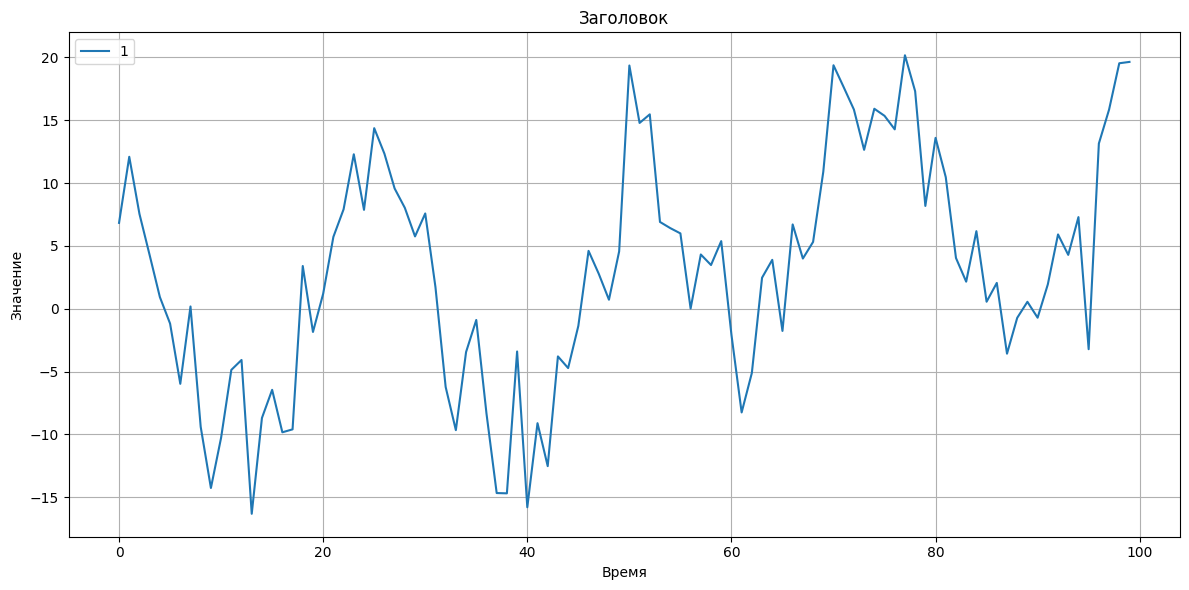

2025-04-03 05:46:38 - [core.generation.ts_datasets] - DEBUG - series 9: [ 7.59362651e+00  1.64649572e+00  1.01891154e+01  9.87003651e+00
  7.33699732e+00 -8.30379008e+00 -1.97333869e+00 -1.24374950e+01
 -2.67770677e+00 -1.06831481e+01 -1.65898526e+01 -1.17418898e+01
 -1.16207273e+01 -1.00476457e+01 -1.34547323e+00 -4.91953055e+00
 -4.16999191e+00 -7.15010428e+00 -1.71171710e-01  8.42950773e+00
 -1.79345566e+00  6.33105769e+00  1.00930491e+01  1.39868816e+01
  1.12650277e+01  5.80359169e+00  1.12520557e+01  1.21871302e+01
  4.77378304e+00  3.66255198e+00  1.08150031e+01 -1.16580080e+00
  1.60151470e+00 -2.53289468e+00 -4.19184355e+00 -1.04846345e+01
 -5.83892342e+00 -8.05169095e+00 -9.54777099e+00 -1.15023758e+01
 -8.21631984e+00 -1.12571124e+01 -6.65983810e+00 -2.65169040e+00
 -9.13752425e+00  3.15189901e+00  7.19404175e+00  2.07407121e+00
  7.99008168e+00  8.61001546e+00  1.99102814e+01  1.31613623e+01
  8.21529739e+00  1.24843488e+01  1.06271958e+01  4.70537697e+00
  3.08517947e-03  

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


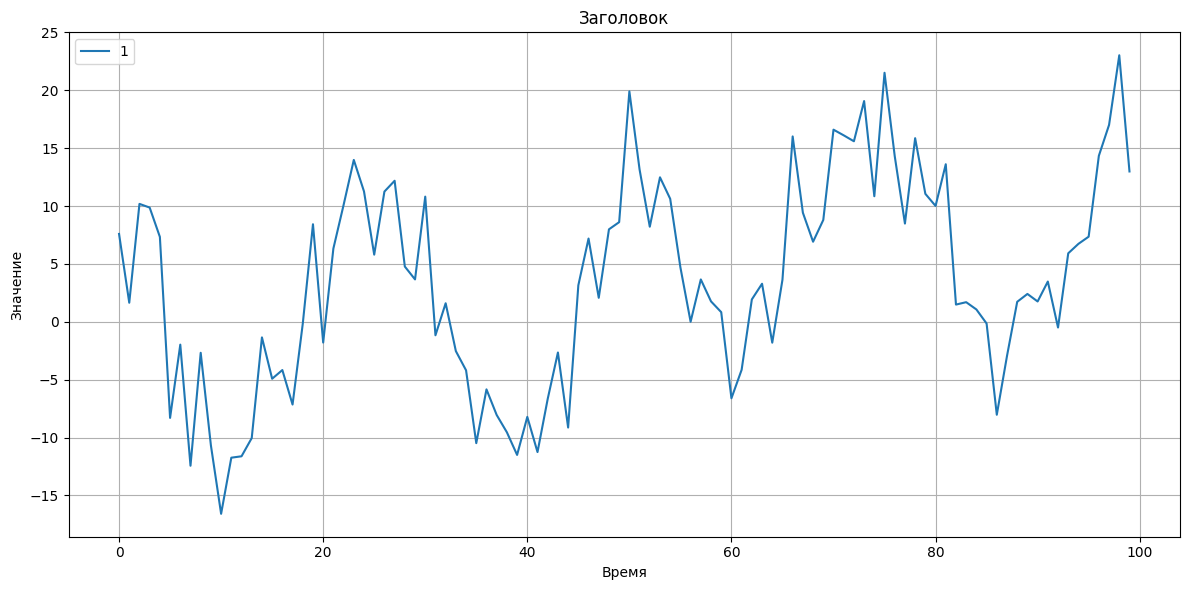

{'general': {'num_classes': 2, 'series_per_class': 10, 'num_blocks': 2, 'block_length': 50, 'random_state': 21, 'generation_function_params': {'seasonal': {'k': 1, 'amplitude_d': 1, 'amplitude_u': 10, 'amplitude_q': 10, 'frequency_d': 1.0, 'frequency_u': 2.0, 'frequency_q': 10, 'phase_d': 1, 'phase_u': 3.14, 'phase_q': 10}}}, 'series_generation': [{'class_id': 1, 'blocks': [{'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}, {'type': 'seasonal', 'params': {'amplitude': 10.0, 'frequency': 1.8888888888888888, 'phase': 1.951111111111111}}]}, {'class_id': 2, 'blocks': [{'type': 'linear', 'params': {'slope': -0.052631578947368474}}, {'type': 'linear', 'params': {'slope': -0.052631578947368474}}]}], 'output': {'save_path': 'data/synthetic_dataset1.json'}}


In [3]:
dt1 = Synthetic_dataset('data/synthetic_dataset1.json')

for i in range(10):
    series, lbl = dt1[i]

    plot_series(series, lbl)

    print(dt1.configs)

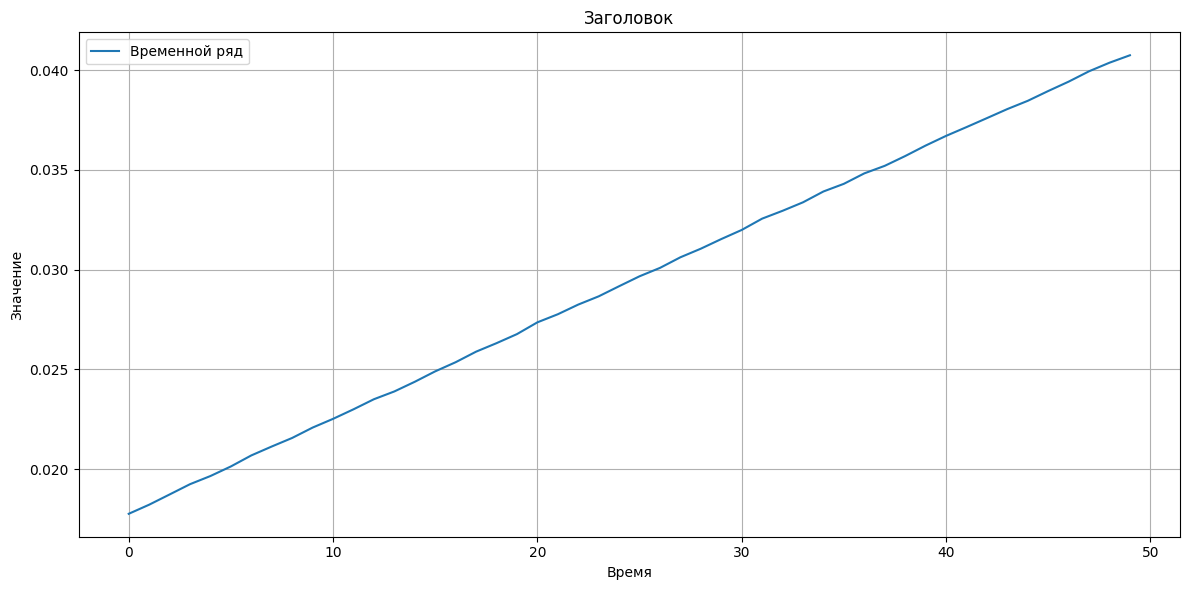

In [16]:
plot_series(seasonal_series(**dt1.configs['series_generation'][0]['blocks'][1]['params'], length=dt1.configs['general']['block_length'], only_array=True, random_state=dt1.configs['general']['random_state']))